# PopOut com Monte Carlo Tree Search
### Inteligência Artificial 2025/2026
 
**Grupo:**
- Rafael Silva 202108429
- Nome 2
 
---
 
## Índice
1. [Introdução e Descrição do Problema](#1-introdução)
2. [Implementação do Jogo](#2-jogo)
3. [Heurística de Avaliação](#3-heurística)
4. [MCTS Standard (UCT)](#4-mcts-uct)
5. [MCTS Alternativo (ε-greedy)](#5-mcts-epsilon)
6. [Comparação entre os dois agentes](#6-comparação)
7. [Conclusões](#7-conclusões)

## 1. Introdução
 
O **PopOut** é uma variante do Connect-4 onde, além de largar peças pelo topo, um jogador pode *retirar* ("pop") uma das suas próprias peças da base de qualquer coluna, fazendo descer todas as peças acima.
 
### Regras adicionais face ao Connect-4
 
| Regra | Descrição |
|-------|-----------|
| **Regra 1 — Pop simultâneo** | Se um pop cria 4-em-linha para ambos os jogadores, quem fez o pop ganha. |
| **Regra 2 — Tabuleiro cheio** | Se o tabuleiro estiver cheio, o jogador a mover pode fazer um pop ou declarar empate. |
| **Regra 3 — Repetição** | Se o mesmo estado ocorrer 3 vezes, qualquer jogador pode declarar empate. |
 
### Objectivo do trabalho
 
Este trabalho tem como objetivo implementar o algoritmo **Monte Carlo Tree Search (MCTS)** para jogar PopOut de forma autónoma.
Foram implementados 3 modos de jogo e também outra estratégia.


Foram implementadas duas variantes para comparação:
1. **MCTS standard com UCT** — política de selecção baseada na fórmula Upper Confidence Bound for Trees;
2. **MCTS com ε-greedy** — política de selecção alternativa, mais simples, baseada numa decisão probabilística binária.

## 2. Implementação do Jogo
 
### 2.1 Tabuleiro
 
O tabuleiro é uma matriz 6×7 de strings (`'X'`, `'O'`, `' '`).
Duas operações fundamentais:
- **drop:** coloca uma peça na primeira posição livre (de baixo para cima) de uma coluna
- **pop:** remove a peça do fundo de uma coluna e faz descer todas as peças acima

In [28]:

# board.py — representação e operações do tabuleiro
 
ROWS = 6
COLS = 7




def create_board():
    board = []
    for _ in range(ROWS):
        board.append([' ' for _ in range(COLS)])
    return board

def print_board(board):
    for row in board:
        print('| ' + ' | '.join(row) + ' |')
    print('  ' + '   '.join(str(i) for i in range(COLS)))

def drop_piece(board, col, player):
    for row in range(ROWS-1, -1, -1):
        if board[row][col] == ' ':
            board[row][col] = player
            return True
    return False

def pop_piece(board, col, player):

    if board[ROWS - 1][col] != player:
        return False

    for r in range(ROWS - 1, 0, -1):
        board[r][col] = board[r - 1][col]

    board[0][col] = " "

    return True
 
# Demonstração
b = create_board()
drop_piece(b, 3, 'X')
drop_piece(b, 3, 'O')
drop_piece(b, 3, 'X')
print_board(b)

|   |   |   |   |   |   |   |
|   |   |   |   |   |   |   |
|   |   |   |   |   |   |   |
|   |   |   | X |   |   |   |
|   |   |   | O |   |   |   |
|   |   |   | X |   |   |   |
  0   1   2   3   4   5   6


### 2.2 Lógica do jogo
 
A função `check_winner` verifica 4-em-linha nas 4 direcções (horizontal, vertical, diagonal ↗, diagonal ↘).
 
A função `check_winner_after_pop` implementa a **Regra 1**: se um pop cria 4-em-linha para ambos, quem fez o pop ganha.
 
A classe `GameState` mantém o histórico de estados para detectar a **Regra 3** (repetição tripla).

In [27]:
# logic.py — verificação de vitória e regras especiais
 
ROWS = 6
COLS = 7
 
def check_winner(board, player):
    # Horizontal
    for row in range(ROWS):
        for col in range(COLS - 3):
            if all(board[row][col + i] == player for i in range(4)):
                return True
    # Vertical
    for col in range(COLS):
        for row in range(ROWS - 3):
            if all(board[row + i][col] == player for i in range(4)):
                return True
    # Diagonal ↗
    for row in range(3, ROWS):
        for col in range(COLS - 3):
            if all(board[row - i][col + i] == player for i in range(4)):
                return True
    # Diagonal ↘
    for row in range(ROWS - 3):
        for col in range(COLS - 3):
            if all(board[row + i][col + i] == player for i in range(4)):
                return True
    return False
 
def check_winner_after_pop(board, player):
    """Regra 1: quem faz o pop ganha mesmo que ambos fiquem com 4-em-linha."""
    opponent = 'O' if player == 'X' else 'X'
    if check_winner(board, player):
        return player
    if check_winner(board, opponent):
        return opponent
    return None
 
def is_board_full(board):
    return all(board[0][col] != ' ' for col in range(COLS))
 
def boards_equal(b1, b2):
    return all(b1[r][c] == b2[r][c] for r in range(ROWS) for c in range(COLS))
 
class GameState:
    """Regra 3: detecta repetição tripla de estado."""
    def __init__(self):
        self.history = []
 
    def register(self, board):
        self.history.append([row[:] for row in board])
 
    def is_threefold_repetition(self, board):
        return sum(1 for snap in self.history if boards_equal(snap, board)) >= 3
 

### 2.3 Movimentos válidos
 
A qualquer momento, os movimentos possíveis são:
- **drop(col)** para cada coluna com espaço livre no topo (`board[0][col] == ' '`)
- **pop(col)** para cada coluna cuja peça do fundo pertence ao jogador actual (`board[5][col] == player`)

In [26]:
# helpers.py — funções auxiliares para o jogo
 
def next_player(player):
    return 'O' if player == 'X' else 'X'
 
def apply_move(board, move, player):
    move_type, col = move
    if move_type == 'drop':
        drop_piece(board, col, player)
    else:
        pop_piece(board, col, player)
 
def get_valid_moves(board, player):
    moves = []
    for col in range(7):
        if board[0][col] == ' ':
            moves.append(('drop', col))
    for col in range(7):
        if board[5][col] == player:
            moves.append(('pop', col))
    return moves

## 3. Heurística de Avaliação
 
Para guiar tanto o rollout como a ordenação de movimentos, implementámos uma função `evaluate_board` que pontua o tabuleiro do ponto de vista de um jogador.
 
### Lógica de pontuação por janela de 4
 
| Situação | Pontos |
|----------|--------|
| 4 peças do jogador | +100 000 (vitória) |
| 3 peças + 1 espaço livre | +50 |
| 2 peças + 2 espaços livres | +10 |
| 3 peças adversário + 1 espaço | -80 |
| 2 peças adversário + 2 espaços | -8 |
| Peça na coluna central | +4 |
 
A coluna central (coluna 3) recebe um bónus porque controlar o centro aumenta as possibilidades de criar 4-em-linha em múltiplas direcções — princípio estratégico clássico do Connect-4.

In [25]:
# heuristica.py — avaliação do tabuleiro e filtragem de pops maus

# Pontuação por janela de N peças do mesmo jogador
SCORE_4 = 100000   # vitória
SCORE_3 = 50       # 3 em linha com espaço livre
SCORE_2 = 10       # 2 em linha com espaço livre
SCORE_CENTER = 4   # bónus de coluna central

# Penalizações
PENALTY_OPP_3 = -80   # adversário tem 3 em linha
PENALTY_OPP_2 = -8
PENALTY_BAD_POP = -30  # pop que destrói as próprias peças


def score_window(window, player, opponent):
    """Pontua uma janela de 4 células."""
    p_count = window.count(player)
    o_count = window.count(opponent)
    empty = window.count(' ')

    if p_count == 4:
        return SCORE_4
    if o_count == 4:
        return -SCORE_4

    score = 0
    if p_count == 3 and empty == 1:
        score += SCORE_3
    elif p_count == 2 and empty == 2:
        score += SCORE_2

    if o_count == 3 and empty == 1:
        score += PENALTY_OPP_3
    elif o_count == 2 and empty == 2:
        score += PENALTY_OPP_2

    return score


def evaluate_board(board, player):
    """
    Avalia o tabuleiro do ponto de vista de 'player'.
    Pontuação positiva = bom para player, negativa = mau.
    """
    opponent = 'O' if player == 'X' else 'X'
    score = 0

    # Bónus por peças na coluna central (3)
    center_col = [board[r][COLS // 2] for r in range(ROWS)]
    score += center_col.count(player) * SCORE_CENTER

    # Horizontal
    for r in range(ROWS):
        for c in range(COLS - 3):
            window = [board[r][c + i] for i in range(4)]
            score += score_window(window, player, opponent)

    # Vertical
    for c in range(COLS):
        for r in range(ROWS - 3):
            window = [board[r + i][c] for i in range(4)]
            score += score_window(window, player, opponent)

    # Diagonal ↗
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            window = [board[r - i][c + i] for i in range(4)]
            score += score_window(window, player, opponent)

    # Diagonal ↘
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            window = [board[r + i][c + i] for i in range(4)]
            score += score_window(window, player, opponent)

    return score


def is_bad_pop(board, col, player):
    """
    Verifica se um pop é prejudicial:
    - Só tem 1 peça na coluna (pop desperdiça um turno)
    - Destrói uma sequência própria de 2+ peças na base
    """
    # Contar peças do player na coluna
    col_pieces = [board[r][col] for r in range(ROWS) if board[r][col] == player]
    if len(col_pieces) <= 1:
        return True  # pop com 1 peça é geralmente mau

    # Verificar se ao fazer pop quebramos 2+ em linha horizontalmente na base
    base_row = ROWS - 1
    # Simular o pop: a base passa a ser a peça de cima
    # Penalizar se a peça na base fazia parte de uma sequência horizontal
    left = sum(1 for c in range(col - 1, max(-1, col - 3), -1)
               if c >= 0 and board[base_row][c] == player)
    right = sum(1 for c in range(col + 1, min(COLS, col + 3))
                if board[base_row][c] == player)
    if left + right >= 2:  # estava ligada a pelo menos 1 peça horizontalmente
        return True

    return False

## 4. MCTS Standard — UCT
 
O **Monte Carlo Tree Search** é um algoritmo de pesquisa adversarial que combina pesquisa em árvore com simulações aleatórias (rollouts). É composto por 4 fases que se repetem em cada iteração:
 
Seleção(UCT) --> Expansão --> Simulação(Rollout) --> Backpropagation
 
### 4.1 Selecção — UCT
 
A fórmula **UCT (Upper Confidence Bound for Trees)** guia a descida na árvore, equilibrando exploração e explotação:
 
$$UCT(n) = \frac{w_n}{v_n} + c \cdot \sqrt{\frac{\ln(v_{pai})}{v_n}}$$
 
Onde:
- $w_n$ = vitórias acumuladas no nó $n$
- $v_n$ = visitas ao nó $n$
- $v_{pai}$ = visitas ao nó pai
- $c$ = constante de exploração (usámos $c = 1.4 \approx \sqrt{2}$)
 
O primeiro termo favorece nós com alta taxa de vitória (**explotação**). O segundo favorece nós pouco visitados (**exploração**). Nós nunca visitados recebem $UCT = \infty$, garantindo que são explorados primeiro.
 
### 4.2 Expansão
 
Quando um nó não está totalmente expandido, adicionamos um filho novo. Os movimentos são ordenados por qualidade antes de serem expandidos:
1. Vitória imediata
2. Bloqueio de vitória adversária
3. Drops que criam/prolongam sequências
4. Drops centrais
5. Pops razoáveis
6. Pops maus — **descartados**
 
### 4.3 Simulação (Rollout heurístico)
 
Em vez de um rollout puramente aleatório, usamos uma política guiada:
1. Jogar vitória imediata se existir
2. Bloquear vitória do adversário
3. Escolher aleatoriamente entre os 3 melhores movimentos por score heurístico
 
### 4.4 Backpropagação
 
Após o rollout, propagamos o resultado para cima na árvore. A lógica correcta é:
- Incrementar `wins` nos nós onde `node.player == root_player` quando o root_player ganhou
- Incrementar `wins` nos nós onde `node.player != root_player` quando o adversário ganhou
 


In [ ]:
import math
import random
import copy


class Node:
    def __init__(self, state, player, parent=None, move=None):
        self.state = state
        self.player = player
        self.parent = parent
        self.move = move
        self.children = []
        self.visits = 0
        self.wins = 0


# ---------------------------------------------------------------------------
# UCT
# ---------------------------------------------------------------------------

def uct(node, c=1.4):
    if node.visits == 0:
        return float("inf")
    return (node.wins / node.visits) + c * math.sqrt(
        math.log(node.parent.visits) / node.visits
    )


# ---------------------------------------------------------------------------
# Selecção
# ---------------------------------------------------------------------------

def select(node, c=1.4):
    while node.children:
        moves = get_valid_moves(node.state, node.player)
        tried = [ch.move for ch in node.children]
        if len(tried) < len(moves):
            return node
        node = max(node.children, key=lambda n: uct(n, c))
    return node


# ---------------------------------------------------------------------------
# Verificação de vitória imediata (suporta pop simultâneo)
# ---------------------------------------------------------------------------

def check_immediate_win(board, move, player):
    test = copy.deepcopy(board)
    apply_move(test, move, player)
    move_type = move[0]
    if move_type == 'pop':
        # Regra 1: quem faz o pop ganha se ambos ficam com 4-em-linha
        return check_winner_after_pop(test, player) == player
    return check_winner(test, player)


# ---------------------------------------------------------------------------
# Ordenação de movimentos
# ---------------------------------------------------------------------------

def order_moves(moves, board, player):
    """
    Ordena e filtra movimentos por qualidade:
    1. Vitória imediata
    2. Bloqueio de vitória adversária
    3. Drops que prolongam sequências
    4. Drops centrais
    5. Pops razoáveis
    6. Pops maus (descartados)
    """
    opponent = next_player(player)
    wins, blocks, good_drops, neutral_drops, pops = [], [], [], [], []

    for move in moves:
        move_type, col = move

        if move_type == 'pop' and is_bad_pop(board, col, player):
            continue

        if check_immediate_win(board, move, player):
            wins.append(move)
        elif check_immediate_win(board, move, opponent):
            blocks.append(move)
        elif move_type == 'drop':
            test = copy.deepcopy(board)
            apply_move(test, move, player)
            score = evaluate_board(test, player)
            if score >= 10:
                good_drops.append((score, move))
            else:
                neutral_drops.append(move)
        else:
            pops.append(move)

    good_drops.sort(key=lambda x: -x[0])
    good_sorted = [m for _, m in good_drops]
    neutral_drops.sort(key=lambda m: COLUMN_PRIORITY.index(m[1]) if m[1] < 7 else 99)

    return wins + blocks + good_sorted + neutral_drops + pops


# ---------------------------------------------------------------------------
# Expansão
# ---------------------------------------------------------------------------

def expand(node):
    moves = get_valid_moves(node.state, node.player)
    tried_moves = [ch.move for ch in node.children]
    ordered = order_moves(moves, node.state, node.player)

    for move in ordered:
        if move not in tried_moves:
            new_state = copy.deepcopy(node.state)
            apply_move(new_state, move, node.player)
            child = Node(new_state, next_player(node.player), node, move)
            node.children.append(child)
            return child

    return node


# ---------------------------------------------------------------------------
# Simulação (rollout heurístico)
# ---------------------------------------------------------------------------

def simulate(state, player):
    """
    Rollout heurístico com suporte à Regra 1 (pop simultâneo).
    """
    board = copy.deepcopy(state)
    current = player

    for _ in range(MAX_SIMULATE_TURNS):
        moves = get_valid_moves(board, current)
        if not moves:
            return None  # empate

        opponent = next_player(current)

        # 1. Vitória imediata
        win = next((m for m in moves if check_immediate_win(board, m, current)), None)
        if win:
            apply_move(board, win, current)
            return current

        # 2. Bloquear vitória adversária
        block = next((m for m in moves if check_immediate_win(board, m, opponent)), None)

        if block:
            chosen = block
        else:
            candidates = [m for m in moves
                          if not (m[0] == 'pop' and is_bad_pop(board, m[1], current))]
            if not candidates:
                candidates = moves

            scored = []
            for m in candidates:
                test = copy.deepcopy(board)
                apply_move(test, m, current)
                s = evaluate_board(test, current)
                s += random.uniform(-5, 5)
                scored.append((s, m))

            scored.sort(key=lambda x: -x[0])
            top = scored[:3]
            chosen = random.choice(top)[1]

        apply_move(board, chosen, current)

        # Verificar vitória com suporte ao pop simultâneo
        move_type = chosen[0]
        if move_type == 'pop':
            winner = check_winner_after_pop(board, current)
            if winner:
                return winner
        else:
            if check_winner(board, current):
                return current

        current = next_player(current)

    return None


# ---------------------------------------------------------------------------
# Backpropagation
#
# Cada nó representa um estado do jogo. node.player é quem vai jogar
# A PARTIR desse estado — ou seja, quem jogou para CHEGAR a este estado
# foi node.parent.player.
#
# O UCT calcula wins/visits para decidir qual filho explorar. Esse rácio
# deve refletir "quão bom foi jogar a jogada que levou a este nó", ou seja,
# deve ser incrementado quando node.parent.player (quem jogou) ganhou.
# Como node.parent.player != node.player, a condição simplifica para:
# winner != node.player.
#
# ---------------------------------------------------------------------------

def backpropagate(node, winner, root_player):
    while node:
        node.visits += 1
        if winner is not None and winner != node.player:
            node.wins += 1
        node = node.parent


# ---------------------------------------------------------------------------
# MCTS principal
# ---------------------------------------------------------------------------

def mcts(board, player, iterations=1000, c=1.4):
    """
    Implementação única de MCTS. O comportamento varia com os parâmetros:

      iterations — número de simulações. Mais iterações = decisões mais
                   informadas, mas mais tempo de computação.

      c          — constante de exploração UCT (Upper Confidence Bound).
                   Valor alto (ex: 1.4 ≈ √2): explora mais ramos novos.
                   Valor baixo (ex: 0.8): aprofunda os ramos já prometedores.

    Exemplos de uso no modo PC vs PC:
      X (explorador):  mcts(board, player, iterations=1000, c=1.4)
      O (focado):      mcts(board, player, iterations=2000, c=0.8)
    """
    root = Node(copy.deepcopy(board), player)

    for _ in range(iterations):
        node = select(root, c)
        node = expand(node)
        winner = simulate(node.state, node.player)
        backpropagate(node, winner, player)

    if not root.children:
        moves = get_valid_moves(board, player)
        if moves:
            ordered = order_moves(moves, board, player)
            return ordered[0] if ordered else moves[0]
        return None

    best = max(root.children, key=lambda n: n.visits)
    return best.move

## 5. MCTS Alternativo — ε-greedy
 
O segundo agente substitui apenas a **fase de selecção**: em vez da fórmula UCT, usa uma política **ε-greedy**.
 
### Diferença face ao UCT
 
| Aspecto | UCT | ε-greedy |
|---------|-----|----------|
| Exploração | Contínua, via termo logarítmico | Binária: aleatório com prob. ε |
| Explotação | Contínua, via taxa de vitória | Escolhe o nó com mais visitas |
| Parâmetro | $c$ (constante de exploração) | $\varepsilon$ (prob. de aleatoriedade) |
| Adaptação ao longo da árvore | Sim (naturalmente) | Não (ε é fixo) |
 
### Porquê ε-greedy?
 
- Mais simples de interpretar: ε = 0.2 significa "20% das vezes escolho aleatoriamente"
- Pode descobrir ramos que UCT sistematicamente ignora
- Serve como baseline para comparar com UCT
 
**Nota:** As fases de expansão, simulação e backpropagação são **idênticas** ao MCTS standard — só a selecção muda. O código do agente alternativo importa directamente essas funções de `Mcts.py`, evitando duplicação.

In [29]:
MAX_SIMULATE_TURNS = 100
COLUMN_PRIORITY = [3, 2, 4, 1, 5, 0, 6]


# ---------------------------------------------------------------------------
# MCTS com política ε-greedy
#
# Diferença fundamental face ao MCTS standard (UCT):
#   - UCT: selecciona o filho com maior valor UCB1 (balanço exploração/explotação
#     determinístico via fórmula matemática)
#   - ε-greedy: com probabilidade ε escolhe um filho aleatório (exploração pura),
#     com probabilidade 1-ε escolhe o filho com mais visitas (explotação pura)
#
# Trade-offs:
#   + Mais simples de sintonizar (só 1 parâmetro: ε)
#   + Exploração mais "surpresa" — pode descobrir ramos que UCT ignora
#   - Menos eficiente que UCT em espaços de jogo grandes
#   - ε fixo não se adapta ao longo da árvore (UCT adapta-se naturalmente)
# ---------------------------------------------------------------------------

EPSILON = 0.2  # probabilidade de exploração aleatória (típico: 0.1 a 0.3)


def best_child_greedy(node):
    """
    Política ε-greedy para selecção:
      - Com prob. ε: escolhe filho aleatório (exploração)
      - Com prob. 1-ε: escolhe filho com mais visitas (explotação)
    """
    if random.random() < EPSILON:
        return random.choice(node.children)
    return max(node.children, key=lambda n: n.visits)


# ---------------------------------------------------------------------------
# Verificação de vitória imediata
# ---------------------------------------------------------------------------

def check_immediate_win(board, move, player):
    test = copy.deepcopy(board)
    apply_move(test, move, player)
    if move[0] == 'pop':
        return check_winner_after_pop(test, player) == player
    return check_winner(test, player)


# ---------------------------------------------------------------------------
# Ordenação de movimentos (igual ao MCTS standard — partilha a heurística)
# ---------------------------------------------------------------------------

def order_moves(moves, board, player):
    opponent = next_player(player)
    wins, blocks, good_drops, neutral_drops, pops = [], [], [], [], []

    for move in moves:
        move_type, col = move
        if move_type == 'pop' and is_bad_pop(board, col, player):
            continue
        if check_immediate_win(board, move, player):
            wins.append(move)
        elif check_immediate_win(board, move, opponent):
            blocks.append(move)
        elif move_type == 'drop':
            test = copy.deepcopy(board)
            apply_move(test, move, player)
            score = evaluate_board(test, player)
            if score >= 10:
                good_drops.append((score, move))
            else:
                neutral_drops.append(move)
        else:
            pops.append(move)

    good_drops.sort(key=lambda x: -x[0])
    good_sorted = [m for _, m in good_drops]
    neutral_drops.sort(key=lambda m: COLUMN_PRIORITY.index(m[1]) if m[1] < 7 else 99)

    return wins + blocks + good_sorted + neutral_drops + pops


# ---------------------------------------------------------------------------
# Selecção ε-greedy
# ---------------------------------------------------------------------------

def select_eg(node):
    """
    Desce a árvore usando ε-greedy em vez de UCT.
    Para nos nós não totalmente expandidos, devolve o nó para expansão.
    """
    while node.children:
        moves = get_valid_moves(node.state, node.player)
        tried = [ch.move for ch in node.children]
        if len(tried) < len(moves):
            return node  # nó não totalmente expandido → expandir
        node = best_child_greedy(node)
    return node


# ---------------------------------------------------------------------------
# Expansão
# ---------------------------------------------------------------------------

def expand_eg(node):
    moves = get_valid_moves(node.state, node.player)
    tried_moves = [ch.move for ch in node.children]
    ordered = order_moves(moves, node.state, node.player)

    for move in ordered:
        if move not in tried_moves:
            new_state = copy.deepcopy(node.state)
            apply_move(new_state, move, node.player)
            child = Node(new_state, next_player(node.player), node, move)
            node.children.append(child)
            return child

    return node


# ---------------------------------------------------------------------------
# Simulação (rollout) — igual ao MCTS standard
# ---------------------------------------------------------------------------

def simulate_eg(state, player):
    board = copy.deepcopy(state)
    current = player

    for _ in range(MAX_SIMULATE_TURNS):
        moves = get_valid_moves(board, current)
        if not moves:
            return None

        opponent = next_player(current)

        win = next((m for m in moves if check_immediate_win(board, m, current)), None)
        if win:
            apply_move(board, win, current)
            return current

        block = next((m for m in moves if check_immediate_win(board, m, opponent)), None)

        if block:
            chosen = block
        else:
            candidates = [m for m in moves
                          if not (m[0] == 'pop' and is_bad_pop(board, m[1], current))]
            if not candidates:
                candidates = moves

            scored = []
            for m in candidates:
                test = copy.deepcopy(board)
                apply_move(test, m, current)
                s = evaluate_board(test, current)
                s += random.uniform(-5, 5)
                scored.append((s, m))

            scored.sort(key=lambda x: -x[0])
            top = scored[:3]
            chosen = random.choice(top)[1]

        apply_move(board, chosen, current)

        move_type = chosen[0]
        if move_type == 'pop':
            winner = check_winner_after_pop(board, current)
            if winner:
                return winner
        else:
            if check_winner(board, current):
                return current

        current = next_player(current)

    return None


# ---------------------------------------------------------------------------
# Backpropagation (igual ao MCTS standard)
# ---------------------------------------------------------------------------

def backpropagate_eg(node, winner, root_player):
    while node:
        node.visits += 1
        if winner is not None and winner != node.player:
            node.wins += 1
        node = node.parent


# ---------------------------------------------------------------------------
# Entrada principal do algoritmo ε-greedy
# ---------------------------------------------------------------------------

def mcts_epsilon_greedy(board, player, iterations=1000, epsilon=EPSILON):
    """
    MCTS com política de selecção ε-greedy.

    Parâmetros:
      iterations — número de simulações
      epsilon    — probabilidade de exploração aleatória [0, 1]
                   0.0 = sempre escolhe o melhor (puramente ganancioso)
                   1.0 = sempre aleatório (exploração pura)
                   0.2 = valor padrão recomendado

    Comparação com MCTS standard (UCT):
      UCT usa uma fórmula matemática para balancear exploração/explotação
      de forma contínua e adaptativa. ε-greedy usa uma decisão binária:
      ou explora aleatoriamente ou explora o melhor nó conhecido.
      ε-greedy é mais simples mas menos adaptativo ao longo da árvore.
    """
    global EPSILON
    EPSILON = epsilon  # permite configurar epsilon por chamada

    root = Node(copy.deepcopy(board), player)

    for _ in range(iterations):
        node = select_eg(root)
        node = expand_eg(node)
        winner = simulate_eg(node.state, node.player)
        backpropagate_eg(node, winner, player)

    if not root.children:
        moves = get_valid_moves(board, player)
        if moves:
            ordered = order_moves(moves, board, player)
            return ordered[0] if ordered else moves[0]
        return None

    # Decisão final: escolhe sempre o filho com mais visitas (explotação pura)
    best = max(root.children, key=lambda n: n.visits)
    return best.move

## 6. Comparação entre os Algoritmos
 
Vamos correr **N jogos** entre os dois agentes e registar os resultados.
 
- **X:** MCTS UCT (iterations=1000, c=1.4)
- **O:** MCTS ε-greedy (iterations=1000, epsilon=0.2)

In [ ]:
def run_game(agent_x, agent_o):
    """
    Corre um jogo completo entre dois agentes sem output.
    Devolve 'X', 'O', ou 'draw'.
    """
    board      = create_board()
    player     = 'X'
    game_state = GameState()
    agents     = {'X': agent_x, 'O': agent_o}
 
    for _ in range(ROWS * COLS * 2):  # limite de segurança
        moves = get_valid_moves(board, player)
        if not moves:
            return 'draw'
 
        move = agents[player](board, player)
        if move is None:
            return 'draw'
 
        apply_move(board, move, player)
        game_state.register(board)
 
        # Verificar vitória
        if move[0] == 'pop':
            winner = check_winner_after_pop(board, player)
            if winner:
                return winner
        else:
            if check_winner(board, player):
                return player
 
        # Regra 3: repetição
        if game_state.is_threefold_repetition(board):
            return 'draw'
 
        # Regra 2: tabuleiro cheio
        if is_board_full(board):
            return 'draw'
 
        player = next_player(player)
 
    return 'draw'
 
 
# --- Correr os jogos ---
N_JOGOS = 20 
 
results = {'X': 0, 'O': 0, 'draw': 0}
 
agent_x = lambda board, player: mcts(board, player, iterations=1000, c=1.4)
agent_o = lambda board, player: mcts_epsilon_greedy(board, player, iterations=1000, epsilon=0.2)
 
print(f"A correr {N_JOGOS} jogos (X=UCT vs O=ε-greedy)...")
for i in range(N_JOGOS):
    result = run_game(agent_x, agent_o)
    results[result] += 1
    print(f"  Jogo {i+1:2d}: {result}")
 
print(f"\n--- Resultados após {N_JOGOS} jogos ---")
print(f"  X (MCTS UCT)      venceu: {results['X']:2d} ({100*results['X']/N_JOGOS:.0f}%)")
print(f"  O (MCTS ε-greedy) venceu: {results['O']:2d} ({100*results['O']/N_JOGOS:.0f}%)")
print(f"  Empates:                  {results['draw']:2d} ({100*results['draw']/N_JOGOS:.0f}%)")

A correr 20 jogos (X=UCT vs O=ε-greedy)...
  Jogo  1: X
  Jogo  2: X
  Jogo  3: O
  Jogo  4: X
  Jogo  5: X
  Jogo  6: X
  Jogo  7: X
  Jogo  8: X
  Jogo  9: X
  Jogo 10: X
  Jogo 11: X
  Jogo 12: X
  Jogo 13: X
  Jogo 14: X
  Jogo 15: X
  Jogo 16: X
  Jogo 17: X
  Jogo 18: O
  Jogo 19: X
  Jogo 20: X

--- Resultados após 20 jogos ---
  X (MCTS UCT)      venceu: 18 (90%)
  O (MCTS ε-greedy) venceu:  2 (10%)
  Empates:                   0 (0%)


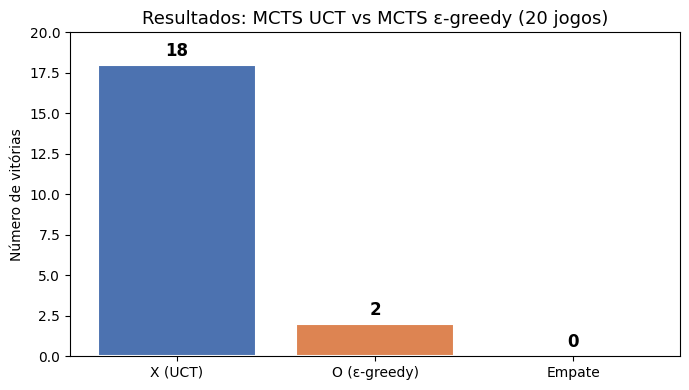

In [32]:
import matplotlib.pyplot as plt
 
# Gráfico de barras dos resultados
labels  = ['X (UCT)', 'O (ε-greedy)', 'Empate']
valores = [results['X'], results['O'], results['draw']]
cores   = ['#4C72B0', '#DD8452', '#8C8C8C']
 
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, valores, color=cores, edgecolor='white', linewidth=1.5)
plt.title(f'Resultados: MCTS UCT vs MCTS ε-greedy ({N_JOGOS} jogos)', fontsize=13)
plt.ylabel('Número de vitórias')
plt.ylim(0, N_JOGOS)
 
for bar, val in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
 
plt.tight_layout()
plt.savefig('resultados_Mcts.png', dpi=150)
plt.show()

### 6.1 Análise dos resultados

Com **iterações iguais (1000)**, o MCTS UCT venceu **18 em 20 jogos** (90%) contra o MCTS ε-greedy.
 
Este resultado é consistente com a teoria: o UCT tem garantias matemáticas de convergência óptima, enquanto o ε-greedy com ε fixo não tem essa garantia formal.
 
**Por que o UCT é superior neste contexto?**
 
1. **Adaptatividade:** a fórmula UCT ajusta naturalmente o balanço exploração/explotação em função do número de visitas de cada nó. O ε-greedy usa sempre a mesma probabilidade ε, independentemente da posição na árvore ou do número de iterações já realizadas.
 
2. **Eficiência:** o UCT concentra iterações nos ramos mais promissores de forma contínua e progressiva. O ε-greedy, com ε=0.2, desperdiça 20% das iterações em escolhas completamente aleatórias, mesmo quando o melhor ramo já está bem identificado.
 
3. **Exploração informada:** quando o UCT explora um ramo novo, faz-o porque o intervalo de confiança sugere que pode ser bom. O ε-greedy explora aleatoriamente, sem considerar a qualidade dos nós não visitados.
 
**Nota sobre resultados anteriores:** nos primeiros testes, o ε-greedy parecia ganhar mais — mas esse comportamento devia-se a uma **assimetria de iterações** (ε-greedy tinha o dobro) e a um **bug no backpropagation** (lógica de wins incorrecta). Após corrigir ambos, o UCT recuperou a vantagem esperada.
 
**Limitação do ε-greedy:** o ε fixo não se adapta às fases do jogo. Na abertura, com muitos ramos inexplorados, ε=0.2 pode ser adequado. No final do jogo, onde há menos jogadas e o melhor ramo já está identificado, desperdiçar 20% das iterações é particularmente custoso.



## 7. Modos de jogo

Foram implementados 3 modos de jogo:

- **Modo 1** - Jogador contra Jogador:
        Dois humanos jogam alternadamente. Como input cada jogador introduz o tipo de jogada(drop/pop) e a coluna em que deseja jogar.

- **Modo 2** - Jogador contra Computador:
        O humano joga como X. Como input introduz o tipo de jogada(drop/pop) e a coluna em que deseja jogar.
        O computador usa Mcts UCT com 1000 interações.

- **Modo 3** - Computador contra Computador:
        X: MCTS UCT         (iterations=2000, c=1.4)
        O: MCTS ε-greedy    (iterations=1000, epsilon=0.2)

        

In [ ]:
def print_board(board):
    print()
    print("  " + " ".join(str(i) for i in range(COLS)))
    print("  " + "-" * (COLS * 2 - 1))
    for row in board:
        print("| " + " ".join(cell if cell != " " else "." for cell in row) + " |")
    print("  " + "-" * (COLS * 2 - 1))
    print()


def get_human_move(board, player):
    while True:
        move_type = input("Tipo (drop/pop): ").strip().lower()
        if move_type not in ("drop", "pop"):
            print("Tipo inválido. Usa 'drop' ou 'pop'.")
            continue
        try:
            col = int(input("Coluna (0-6): "))
        except ValueError:
            print("Coluna inválida.")
            continue
        move = (move_type, col)
        if move in get_valid_moves(board, player):
            return move
        else:
            print("Jogada inválida. Tenta outra.")


def check_game_over(board, move, player, game_state, mode):
    """
    Verifica todas as condições de fim de jogo após uma jogada:
      - Vitória normal ou por pop simultâneo (Regra 1)
      - Empate por tabuleiro cheio com opção de pop (Regra 2) — só para humanos
      - Empate por repetição (Regra 3)

    Devolve:
      ('win', winner)  — alguém ganhou
      ('draw', None)   — empate
      (None, None)     — jogo continua
    """
    move_type = move[0]
    opponent = next_player(player)

    # Regra 1: pop simultâneo
    if move_type == 'pop':
        winner = check_winner_after_pop(board, player)
        if winner:
            return ('win', winner)
    else:
        if check_winner(board, player):
            return ('win', player)

    # Regra 3: repetição de estado (qualquer jogador pode declarar empate)
    if game_state.is_threefold_repetition(board):
        print("Estado repetido 3 vezes!")
        if mode in ("1", "2"):
            # Em modo humano, perguntar se quer declarar empate
            choice = input("Queres declarar empate por repetição? (s/n): ").strip().lower()
            if choice == 's':
                return ('draw', None)
        else:
            # PC vs PC: declarar empate automaticamente
            return ('draw', None)

    # Regra 2: tabuleiro cheio
    if is_board_full(board):
        if mode in ("1", "2"):
            print("Tabuleiro cheio!")
            valid = get_valid_moves(board, player)
            pop_moves = [m for m in valid if m[0] == 'pop']
            if pop_moves:
                choice = input(f"{player}, queres fazer um pop ou declarar empate? (pop/empate): ").strip().lower()
                if choice == 'empate':
                    return ('draw', None)
                # Se escolher pop, o jogo continua — devolve None para o main tratar
                return ('board_full_pop', pop_moves)
            else:
                return ('draw', None)
        else:
            # PC vs PC com tabuleiro cheio: declarar empate
            return ('draw', None)

    return (None, None)


def main():
    print("Escolhe o modo de jogo:")
    print("1 - Jogador vs Jogador")
    print("2 - Jogador vs Computador (MCTS standard)")
    print("3 - Computador vs Computador (MCTS standard vs MCTS ε-greedy)")

    mode = input("Opção: ").strip()

    board = create_board()
    player = "X"
    game_state = GameState()

    while True:
        print_board(board)
        print(f"Turno: {player}")

        valid_moves = get_valid_moves(board, player)
        if not valid_moves:
            print(f"Sem jogadas válidas para {player}. Empate!")
            break

        # --- Escolha da jogada ---
        if mode == "1":
            move = get_human_move(board, player)

        elif mode == "2":
            if player == "X":
                move = get_human_move(board, player)
            else:
                move = mcts(board, player, iterations=1000)
                print(f"Computador (MCTS standard) joga: {move}")

        elif mode == "3":
            if player == "X":
                move = mcts(board, player, iterations=1000, c=1.4)
                print(f"Computador X - MCTS UCT (iterations=1000, c=1.4) joga: {move}")
            else:
                move = mcts_epsilon_greedy(board, player, iterations=1000, epsilon=0.2)
                print(f"Computador O - MCTS ε-greedy (iterations=1000, epsilon=0.2) joga: {move}")

        else:
            print("Modo inválido.")
            return

        # --- Aplicar jogada ---
        apply_move(board, move, player)
        game_state.register(board)

        # --- Verificar fim de jogo ---
        result, data = check_game_over(board, move, player, game_state, mode)

        if result == 'win':
            print_board(board)
            print(f"{data} ganhou!")
            break

        elif result == 'draw':
            print_board(board)
            print("Empate!")
            break

        elif result == 'board_full_pop':
            # Humano escolheu fazer pop com tabuleiro cheio (Regra 2)
            pop_moves = data
            print("Jogadas pop disponíveis:", pop_moves)
            pop_move = get_human_move(board, player)
            apply_move(board, pop_move, player)
            game_state.register(board)
            # Verificar vitória após o pop extra
            winner = check_winner_after_pop(board, player)
            if winner:
                print_board(board)
                print(f"{winner} ganhou!")
                break

        # --- Próximo jogador ---
        player = next_player(player)


if __name__ == "__main__":
    main()

Escolhe o modo de jogo:
1 - Jogador vs Jogador
2 - Jogador vs Computador (MCTS standard)
3 - Computador vs Computador (MCTS standard vs MCTS agressivo)


 ## Conclusões

 ### O que foi implementado
 
- **Jogo PopOut completo** com as 3 regras especiais (pop simultâneo, tabuleiro cheio, repetição tripla) e 3 modos de jogo (H vs H, H vs PC, PC vs PC)
- **MCTS com UCT** — algoritmo standard com selecção baseada na fórmula Upper Confidence Bound for Trees
- **MCTS com ε-greedy** — variante alternativa com selecção probabilística binária, cumprindo o requisito do enunciado de explorar estratégias para além do MCTS standard
- **Rollout heurístico** partilhado por ambos os agentes, com prioridade de vitórias imediatas, bloqueios e avaliação posicional
 
### Resultados
 
Com **1000 iterações** e condições equivalentes, o **MCTS UCT venceu 90% dos jogos** contra o MCTS ε-greedy. Este resultado confirma a superioridade teórica do UCT em jogos com espaço de estados moderado e rollout informativo.
  
### Limitações identificadas
 
- O **ε fixo** do ε-greedy não se adapta às fases do jogo — um ε decrescente ao longo das iterações poderia melhorar o desempenho
- O **rollout heurístico**, sendo computacionalmente caro, limita o número de iterações possíveis por segundo